# LAB5 ขั้นตอนที่ 3–4: ตรวจสอบความสะอาดข้อมูล + แบ่ง Train/Test + ปรับสเกล
ข้อควรระวัง: ต้องแบ่งข้อมูลก่อน แล้วจึง Fit Scaler กับ Train เท่านั้น (กัน Data Leakage)


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
BASE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
(BASE / "results").mkdir(exist_ok=True)
df = pd.read_csv(BASE / "data" / "iris.csv")

จำนวนค่าว่างแต่ละคอลัมน์:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


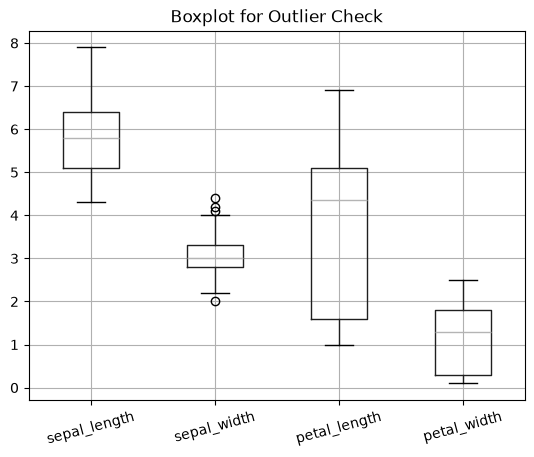


บันทึกกราฟที่ results/02_boxplot.png


In [3]:
# --- ขั้นตอนที่ 3 ตรวจสอบความสะอาด ---
print("จำนวนค่าว่างแต่ละคอลัมน์:")                     # Checkpoint: ทุกคอลัมน์ = 0
print(df.isnull().sum())

df.iloc[:, :4].boxplot()
plt.xticks(rotation=15)
plt.title("Boxplot for Outlier Check")
plt.savefig(BASE / "results" / "02_boxplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nบันทึกกราฟที่ results/02_boxplot.png")

In [4]:
# --- ขั้นตอนที่ 4 แบ่งข้อมูลและปรับสเกล ---
X = df.iloc[:, :4]
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("\nขนาด Train:", X_train.shape, " ขนาด Test:", X_test.shape)  # (120,4) (30,4)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit เฉพาะ Train
X_test_s = scaler.transform(X_test)         # Test ใช้ transform เท่านั้น

print("ค่าเฉลี่ยของ Train หลังปรับสเกล (ควรใกล้ 0):", X_train_s.mean(axis=0).round(3))
print("ส่วนเบี่ยงเบนมาตรฐาน (ควรใกล้ 1):", X_train_s.std(axis=0).round(3))



ขนาด Train: (120, 4)  ขนาด Test: (30, 4)
ค่าเฉลี่ยของ Train หลังปรับสเกล (ควรใกล้ 0): [-0.  0.  0.  0.]
ส่วนเบี่ยงเบนมาตรฐาน (ควรใกล้ 1): [1. 1. 1. 1.]
